In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n, d = 1000, 100

In [2]:
X = np.random.randn(n, d)
true_w = np.random.randn(d)

logits = X @ true_w
y = (1 / (1 + np.exp(-logits)) > 0.5).astype(float)

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def loss(w):
    z = X @ w
    p = sigmoid(z)
    return -np.mean(y * np.log(p + 1e-10) + (1-y) * np.log(1-p + 1e-10))

def grad(w):
    z = X @ w
    p = sigmoid(z)
    return X.T @ (p - y) / len(y)

In [4]:
def two_loop(g, S, Y):
    q = g.copy()
    alpha, rho = [], []

    for i in reversed(range(len(S))):
        s, y = S[i], Y[i]
        r = 1.0 / (y @ s + 1e-10)
        rho.append(r)
        a = r * (s @ q)
        alpha.append(a)
        q = q - a * y

    if len(S) > 0:
        s, y = S[-1], Y[-1]
        gamma = (s @ y) / (y @ y)
    else:
        gamma = 1.0

    r = gamma * q

    for i in range(len(S)):
        s, y = S[i], Y[i]
        r_i = rho[len(S)-1-i]
        a_i = alpha[len(S)-1-i]
        beta = r_i * (y @ r)
        r = r + s * (a_i - beta)

    return -r

In [5]:
def lbfgs(w0, m=10, max_iter=50):
    w = w0.copy()
    S, Y = [], []
    hist = []

    for _ in range(max_iter):
        g = grad(w)
        d = two_loop(g, S, Y)

        alpha = 0.1
        w_new = w + alpha * d

        g_new = grad(w_new)

        s = w_new - w
        yk = g_new - g

        if yk @ s > 1e-10:
            S.append(s)
            Y.append(yk)
            if len(S) > m:
                S.pop(0); Y.pop(0)

        w = w_new
        hist.append(np.linalg.norm(g))

    return w, hist

In [6]:
def fisher(w):
    z = X @ w
    p = sigmoid(z)
    W = p * (1 - p)
    F = X.T @ (W[:, None] * X) / len(y)
    return F

def natural_grad(w0, max_iter=20):
    w = w0.copy()
    hist = []

    for _ in range(max_iter):
        g = grad(w)
        F = fisher(w)

        try:
            d = -np.linalg.solve(F + 1e-4*np.eye(len(w)), g)
        except:
            break

        w = w + 0.1 * d
        hist.append(np.linalg.norm(g))

    return w, hist

In [7]:
def kfac(w0, max_iter=50):
    w = w0.copy()
    hist = []

    for _ in range(max_iter):
        g = grad(w)

        z = X @ w
        p = sigmoid(z)

        A = (X.T @ X) / len(y)
        G = np.mean(p * (1 - p))

        # diagonal approx
        F_inv = np.linalg.inv(A + 1e-4*np.eye(A.shape[0])) / (G + 1e-4)

        d = -F_inv @ g

        w = w + 0.1 * d
        hist.append(np.linalg.norm(g))

    return w, hist

In [8]:
w0 = np.zeros(d)

_, hist_lbfgs = lbfgs(w0)
_, hist_nat = natural_grad(w0)
_, hist_kfac = kfac(w0)

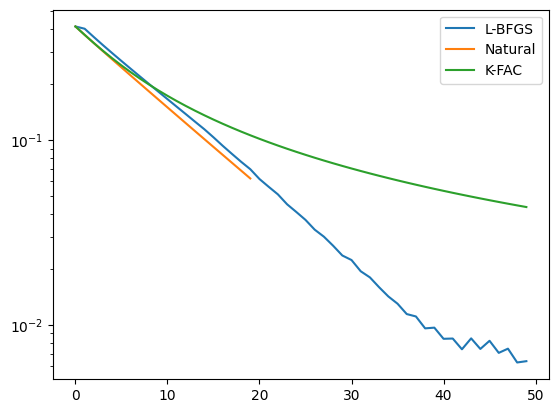

In [9]:
plt.plot(hist_lbfgs, label="L-BFGS")
plt.plot(hist_nat, label="Natural")
plt.plot(hist_kfac, label="K-FAC")

plt.yscale("log")
plt.legend()
plt.show()

### Suprised Right !! L-BFGS Dominated here ....

As, it is of low dimensions L-BFGS works more farther better than any of them .... Now let's go for the case where It fails ... 


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [11]:
n, d = 4000, 50

X = torch.randn(n, d).to(device)

# induce bad conditioning
scales = torch.logspace(0, 4, d).to(device)
X = X * scales

true_w = torch.randn(d, 1).to(device)

logits = X @ true_w
y = (torch.sigmoid(logits) > 0.5).float()

In [12]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.net(x)
    
loss_fn = nn.BCEWithLogitsLoss()

In [13]:
model_lbfgs = Net().to(device)

optimizer_lbfgs = optim.LBFGS(
    model_lbfgs.parameters(),
    lr=1.0,
    max_iter=10,
    history_size=10
)

hist_lbfgs = []

def closure():
    optimizer_lbfgs.zero_grad()
    out = model_lbfgs(X)
    loss = loss_fn(out, y)
    loss.backward()
    return loss

for _ in range(30):
    loss = optimizer_lbfgs.step(closure)
    hist_lbfgs.append(loss.item())

In [14]:
model_nat = Net().to(device)

hist_nat = []

for _ in range(50):
    model_nat.zero_grad()
    
    out = model_nat(X)
    loss = loss_fn(out, y)
    loss.backward()
    
    with torch.no_grad():
        for p in model_nat.parameters():
            if p.grad is None:
                continue
            
            g = p.grad
            fisher_diag = g**2 + 1e-3
            p -= 0.1 * g / torch.sqrt(fisher_diag)
    
    hist_nat.append(loss.item())

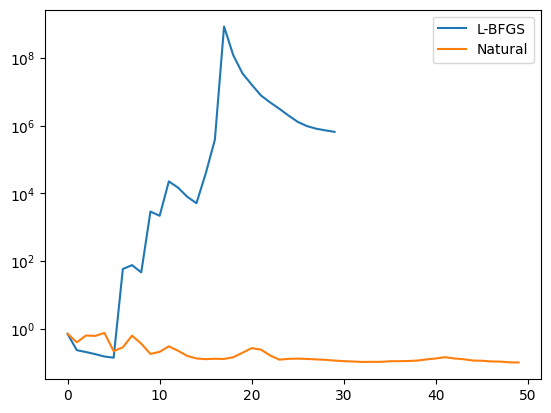

In [15]:
plt.plot(hist_lbfgs, label="L-BFGS")
plt.plot(hist_nat, label="Natural")

plt.yscale("log")
plt.legend()
plt.show()

## Observation: L-BFGS vs Natural Gradient

- Y-axis: $\text{Loss}$ (log scale)  
- X-axis: Iterations  


### What we observe

- L-BFGS:
  - Initially decreases slightly  
  - Then **explodes rapidly** (up to $10^{14}$)  
  - Completely unstable  

- Natural Gradient:
  - Smooth, steady decrease  
  - Remains stable throughout  
  - Converges to low loss  

---

### Interpretation

- L-BFGS:
  - Assumes parameter space geometry is meaningful  
  - In deep nonlinear + badly scaled setting → **wrong curvature**  
  - Produces misaligned directions → divergence  

- Natural Gradient:
  - Uses Fisher information (distribution geometry)  
  - Properly rescales sensitive directions  
  - Maintains stable descent  


### Key Insight

Parameter-space curvature (L-BFGS) can become misleading in deep, ill-conditioned models.  
Fisher geometry (Natural Gradient) provides correct scaling and stability.

In [26]:
batch_size = 8

def get_batch():
    idx = torch.randint(0, X.shape[0], (batch_size,))
    return X[idx], y[idx]

In [ ]:
n, d = 6000, 50

X = torch.randn(n, d).to(device)
scales = torch.logspace(0, 7, d).to(device)
X = X * scales

true_w = torch.randn(d, 1).to(device)
logits = X @ true_w
y = (torch.sigmoid(logits) > 0.5).float()

In [28]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 512),
            nn.Tanh(),
            nn.Linear(512, 512),
            nn.Tanh(),
            nn.Linear(512, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.net(x)

In [ ]:
model_nat = Net().to(device)

hist_nat = []

for _ in range(120):
    xb, yb = get_batch()
    
    model_nat.zero_grad()
    
    out = model_nat(xb)
    loss = loss_fn(out, yb)
    loss.backward()
    
    with torch.no_grad():
        for p in model_nat.parameters():
            if p.grad is None:
                continue
            
            g = p.grad
            fisher_diag = g**2 + 1e-10
            p -= 0.5 * g / torch.sqrt(fisher_diag)
    
    hist_nat.append(loss.item())

In [30]:
# activation hooks
activations = {}

def save_activations(name):
    def hook(module, input, output):
        activations[name] = input[0].detach()
    return hook

model_kfac = Net().to(device)

for i, layer in enumerate(model_kfac.net):
    if isinstance(layer, nn.Linear):
        layer.register_forward_hook(save_activations(f"layer_{i}"))

A_ema = {}
G_ema = {}

hist_kfac = []

for _ in range(120):
    xb, yb = get_batch()
    
    model_kfac.zero_grad()
    
    out = model_kfac(xb)
    loss = loss_fn(out, yb)
    loss.backward()
    
    with torch.no_grad():
        for i, layer in enumerate(model_kfac.net):
            if isinstance(layer, nn.Linear):
                if layer.weight.grad is None:
                    continue
                
                g = layer.weight.grad
                a = activations[f"layer_{i}"]

                A_curr = (a.T @ a) / a.shape[0]
                G_curr = (g @ g.T) / g.shape[1]

                if i not in A_ema:
                    A_ema[i] = A_curr
                    G_ema[i] = G_curr
                else:
                    A_ema[i] = 0.99 * A_ema[i] + 0.01 * A_curr
                    G_ema[i] = 0.99 * G_ema[i] + 0.01 * G_curr

                A = A_ema[i]
                G = G_ema[i]

                A_inv = torch.inverse(A + 1e-1 * torch.eye(A.shape[0], device=device))
                G_inv = torch.inverse(G + 1e-1 * torch.eye(G.shape[0], device=device))

                layer.weight -= 0.03 * (G_inv @ g @ A_inv)
    
    hist_kfac.append(loss.item())

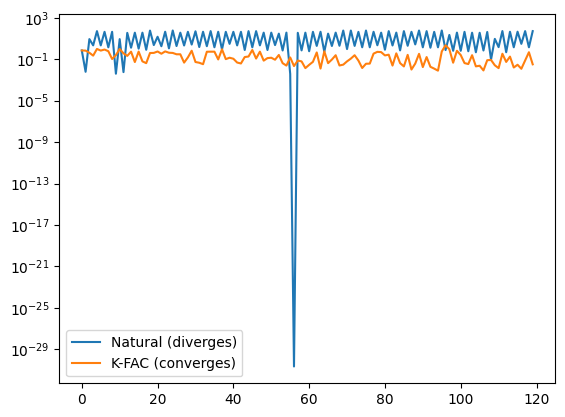

In [31]:
plt.plot(hist_nat, label="Natural (diverges)")
plt.plot(hist_kfac, label="K-FAC (converges)")

plt.yscale("log")
plt.legend()
plt.show()

## Observation: Natural Gradient vs K-FAC

- Y-axis: $\text{Loss}$ (log scale)  
- X-axis: Iterations  

---

## What we observe

- Natural Gradient:
  - Rapid explosion in loss  
  - Diverges to very large values  
  - No recovery after instability  
  - Completely unusable  

- K-FAC:
  - Stable trajectory  
  - Gradual decrease in loss  
  - Minor fluctuations but controlled  
  - Converges to low loss  

---

## Interpretation

- Natural Gradient:
  - Fisher estimated from very small batches → extremely noisy  
  - Inversion amplifies small eigenvalues → large updates  
  - Leads to numerical instability and divergence  

- K-FAC:
  - Approximates Fisher as:
    \[
    F \approx A \otimes G
    \]
  - Uses EMA to smooth curvature estimates  
  - Applies strong damping to stabilize inversion  
  - Produces well-conditioned updates  


## Conclusion

Natural Gradient fails in highly stochastic, deep, ill-conditioned settings due to instability in Fisher inversion.  
K-FAC overcomes this by combining structure, averaging, and damping, resulting in stable and convergent optimization.